#### **OBSERVATIONS:**

1.  The main objective of the Problem statement is to classify the type of the Image based on the cifar10 dataset.

#### **Steps used in the Algorithm:**

1.  Import all the necessary libraries

2.  Load CIFAR-10 Dataset

3.  Reshape the Images

4.  Visualize the Images

5.  Normalize the Data

6.  Convert Labels to One-Hot Encoding

7.  Build the CNN model

8.  Compile the model

9. Get the Model Summary

10. Train the model

11. Evaluate the model

12. Plot the accuracy and the loss

13. Make predictions

14. Visualize predictions

#### **Step 1: Import all the necessary libraries**

In [150]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.utils    import to_categorical

from sklearn.metrics           import accuracy_score, classification_report, confusion_matrix

#### **OBSERVATIONS:**

1.  Conv2D ------------>  It produces the convoluted feature maps.

2.  MaxPooling2D ------>  It performs the dimensional reduction and performs the reduced feature maps.

3.  to_categorical ------> It converts each integer label into one hot encoded form.

4.  Dropout ------->  It reduces overfitting

5.  Flatten ---------->  It converts the pooled feature maps into 1 dimensional feature vectors.

#### **Step 2: Load CIFAR-10 Dataset**

In [151]:
#### Load the cifar10 data
(X_train, Y_train),(X_test, Y_test) = fashion_mnist.load_data()

In [152]:
#### Shape of the training data
print("Shape of the input  training data is:", X_train.shape)
print("Shape of the output training data is:", Y_train.shape)

Shape of the input  training data is: (60000, 28, 28)
Shape of the output training data is: (60000,)


In [153]:
#### Shape of the testing data
print("Shape of the input  testing  data is:", X_test.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the input  testing  data is: (10000, 28, 28)
Shape of the output testing  data is: (10000,)


In [154]:
#### Shape of the input data
print("Shape of the input  training data is:", X_train.shape)
print("Shape of the input  testing  data is:", X_test.shape)

Shape of the input  training data is: (60000, 28, 28)
Shape of the input  testing  data is: (10000, 28, 28)


In [155]:
#### Shape of the output data
print("Shape of the output  training data is:", Y_train.shape)
print("Shape of the output  testing  data is:", Y_test.shape)

Shape of the output  training data is: (60000,)
Shape of the output  testing  data is: (10000,)


#### **OBSERVATIONS:**

1.  There are 60000 training images and 10000 testing images.

2.  The size of the image is (height * width)

3.  For the input data, there are 3 channels namely RGB(R --> Red, G --> Green, B --> Blue) and for the output data, it has only one channel.

#### **Step 3: Reshape the Images**

In [156]:
#### Reshape the input images
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [157]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

#### **OBSERVATIONS:**

1.  The input images (No of training images, height, width) has been converted in the form (No of training images, height, width, no of channels).

2.  This form is accepted as an input for the CNN Model.

#### **Step 4: Visualize the Images**

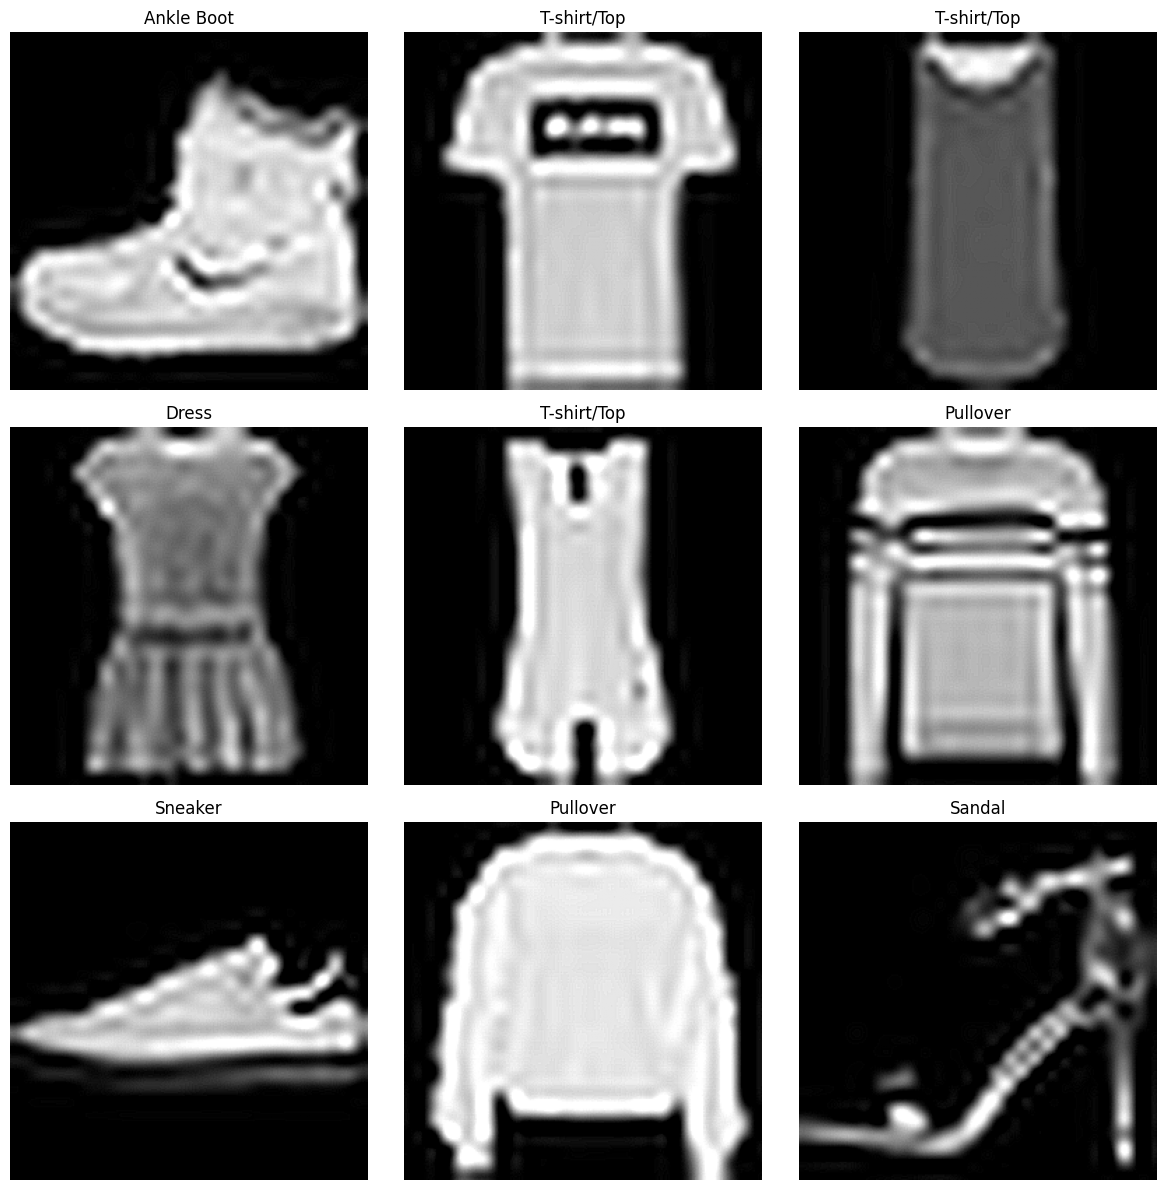

In [134]:
# Class names
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    # Resize image
    img = cv2.resize(
        X_train[i],
        (256,256),
        interpolation=cv2.INTER_LANCZOS4
    )

    # Sharpen image
    kernel = np.array([
        [-1,-1,-1],
        [-1, 9,-1],
        [-1,-1,-1]
    ])

    img = cv2.filter2D(img, -1, kernel)

    plt.imshow(img, cmap='gray')
    plt.title(class_names[Y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

#### **OBSERVATIONS:**

1.  The original image is displayed so as to understand the data before modeling.

#### **Step 5: Normalize the Data**

In [135]:
#### Normalize the pixel values
X_train = X_train/255.0

X_test  = X_test/255.0

In [136]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [137]:
X_test

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

#### **OBSERVATIONS:**

1.  The pixel values are being normalized because:

    (a.)  To provide the numerical stability of the model

    (b.)  It can perform faster training.

    (c.)  The activation functions can work properly.

#### **Step 6: Convert Labels to One-Hot Encoding**

In [138]:
from tensorflow.keras.utils import to_categorical

#### convert the output values into one hot encoded form
Y_train = to_categorical(Y_train, num_classes=10)
print(Y_train)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [139]:
Y_test = to_categorical(Y_test, num_classes=10)
print(Y_test)

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


#### **OBSERVATIONS:**

1.  to_categorical is used to convert each value into one hot encoded form of the size 10.

2.  This is done because the model cannot directly work with the integers. It learns the probability of different classes by applying the softmax activation function on it.

3.  So the output value must be converted into one hot encoded form.

4.  Multiclass classification requires categorical labels

#### **Step 7: Build the CNN model**

In [140]:
#### develop the model for CNN
model = Sequential([
    #### create the first layer for convolutional neural network
    Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1))                      ,
    MaxPooling2D(pool_size=(2,2))                                                                     ,

    #### create the second layer for convolutional neural network
    Conv2D(filters=64,kernel_size=(3,3),activation='relu')                                            ,
    MaxPooling2D(pool_size=(2,2))                                                                     ,

    #### convert the feature maps into the vector
    Flatten()                                                                                         ,

    #### convert the 1d vector as an input into the dense neural network
    Dense(units=128, activation='relu')                                                               ,

    #### reduce the overfitting
    Dropout(0.3)                                                                                      ,

    ### create the output layer
    Dense(units=10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [141]:
model

<Sequential name=sequential_4, built=True>

#### **Step 8: Compile the model**

In [142]:
#### Compile the model
model.compile(
    optimizer    =      'adam'                                  ,
    loss         =      'categorical_crossentropy'              ,
    metrics      =      ['accuracy']
)

#### **Step 9: Get the Model Summary**

In [143]:
#### get the summary of the model
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#### **Step 10: Train the model**

In [144]:
#### Train the model
history=model.fit(
    X_train                                                         ,
    Y_train                                                         ,
    batch_size=64                                                   ,
    epochs=10                                                       ,
    validation_data=(X_test, Y_test)                                ,
    validation_split=0.2                                            ,
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8071 - loss: 0.5346 - val_accuracy: 0.8509 - val_loss: 0.4095
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.8737 - loss: 0.3513 - val_accuracy: 0.8832 - val_loss: 0.3262
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 58ms/step - accuracy: 0.8899 - loss: 0.3023 - val_accuracy: 0.8953 - val_loss: 0.2941
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9018 - loss: 0.2712 - val_accuracy: 0.9013 - val_loss: 0.2728
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9080 - loss: 0.2485 - val_accuracy: 0.9023 - val_loss: 0.2717
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.9157 - loss: 0.2268 - val_accuracy: 0.9070 - val_loss: 0.2558
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9231 - loss: 0.2077 - val_accuracy: 0.9091 - val_loss: 0.2517
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9271 - loss: 0.1962 - 

#### **OBSERVATIONS:**

1.  After training the model, the accuracy and the validation accuracy has increased while the loss and validation loss of the model has reduced.

2.  So, the model is working fine.

#### **Step 11: Evaluate the model**

In [145]:
#### Evaluate the model
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("Loss Function is:", loss)
print("Accuracy is:", accuracy)

Loss Function is: 0.2526865303516388
Accuracy is: 0.9114000201225281


#### **OBSERVATIONS:**

1.  The accuracy of the model is very high but the loss function is very less.

2.  So the model is working fine.

#### **Step 12: Plot the accuracy and the loss**

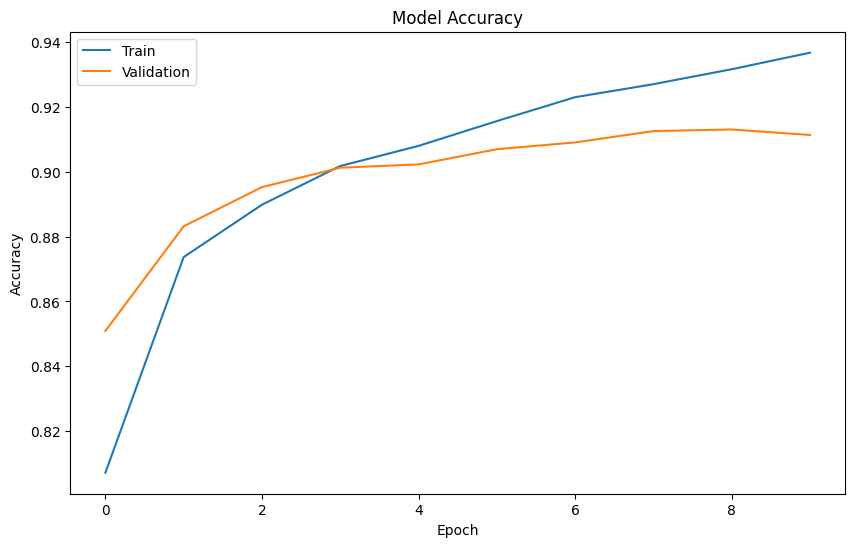

In [146]:
#### Plot the accuracy
plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'], loc = 'upper left')

plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the training and validation accuracy of the model increases.

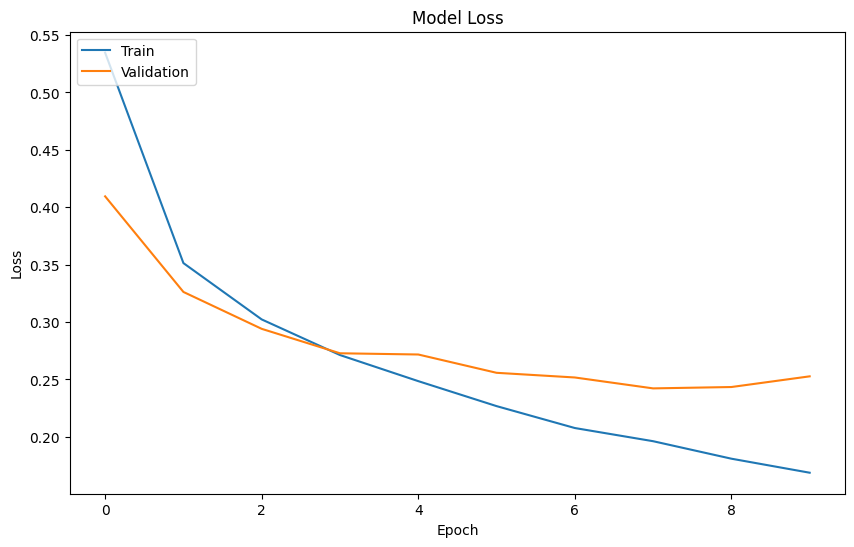

In [147]:
#### Plot the loss
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'], loc = 'upper left')

plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, training and validation loss of the model decreases.

#### **Step 13: Make predictions**

In [148]:
#### Make the predictions for the model
Y_pred = model.predict(X_test)
Y_pred

#### convert all the probabilities into the labels
Y_pred = np.argmax(Y_pred, axis=1)
Y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


array([9, 2, 1, ..., 8, 1, 5])

#### **OBSERVATIONS:**

1.  It finds out the probabilities of each class.

2.  Then it finds out the index of the highest probability for that class.

#### **Step 14: Visualize predictions**

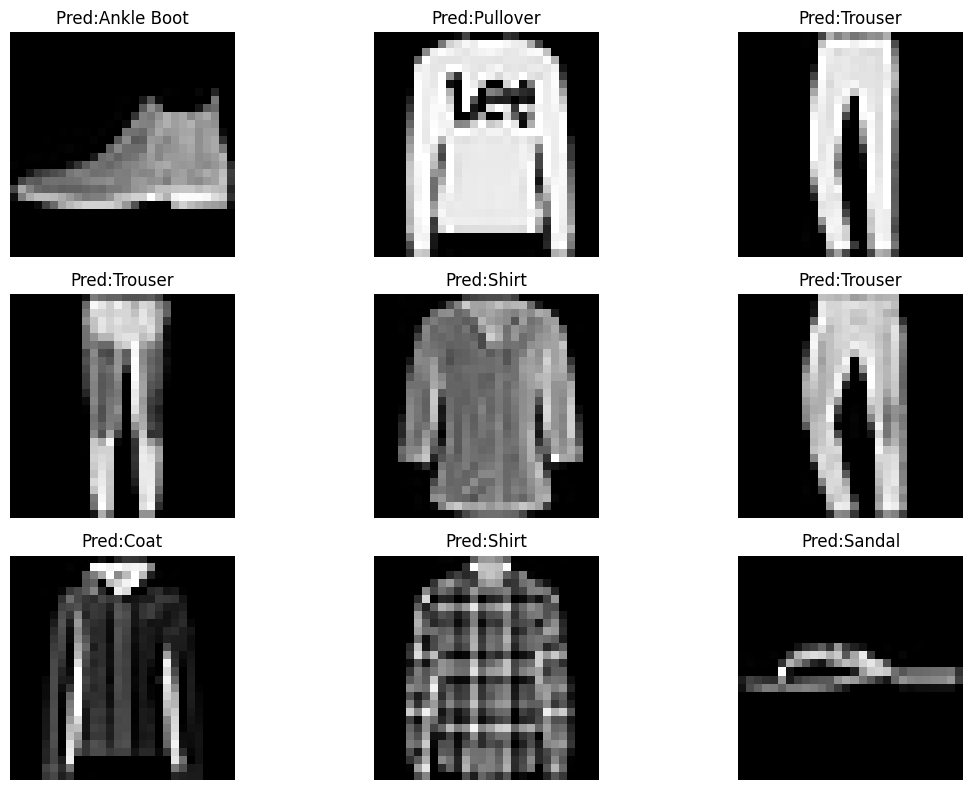

In [149]:
#### Visualize the Predictions

class_names = [
'T-shirt',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle Boot'
]

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Pred:{class_names[Y_pred[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

#### **OBSERVATIONS:**

1.  The images has been predicted for all the predicted outputs.